# Melodic Similarity Analysis

Symbolic melodic similarity algorithm that compares melodies by fitting polynomial curves to pitch and timing contours, then aligning them via a sequence alignment (Smith-Waterman-style Dynamic Programming). Here are the similarity measures used

- **ShapeH score** — shape-histogram alignment
- **Time score** — polynomial time alignment
- **MAD** / **RMSE** / **Fréchet** / **Hausdorff** — curve-distance metrics computed from span polynomials

In [14]:
import sys
import os
import math
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

from raga.pitch_extractor import load_raga_notes
from makam.pitch_extractor import load_makam_notes
from analysis.melodyshape import (
    build_spans,
    compute_span_frequencies,
    shapeh_similarity,
    time_similarity,
    _diff_between_spans,
)
from analysis.utils import similarity_from_distance, discrete_frechet_distance, hausdorff_distance, rmse_distance, mean_abs_distance


RAGA_NAME     = "Bhairav"       # raag name (must match XML metadata)
MAKAM_NAME    = "Hüseynî Türkü"    # makam name (must match XML/filename)
TOP_N         = 5               # top-N most similar phrase pairs to plot
SPAN_N        = 4               # n-note span size for phrase segments
SHAPE_SAMPLES = 40              # polynomial sample resolution per span curve


# Directories
RAGA_DIR   = "datasets/ragas"
MAKAM_DIR  = "datasets/makams"

### Load Precomputed Metrics from Output Directory


In [2]:
PAIRWISE_CSV = "analysis/output/pairwise_similarity.csv"
AGG_CSV      = "analysis/output/agg_similarity_by_raga_makam_usul.csv"

In [13]:
df_agg = pd.read_csv(AGG_CSV)
df_agg.head()

,raga,makam,usul,metric,agg,value
0,Bhairav,Acem İlâhî,Düyek,shapeh_score,mean,26.477405
1,Bhairav,Acem İlâhî,Düyek,shapeh_score,median,24.907774
2,Bhairav,Acem İlâhî,Düyek,shapeh_score,max,43.086750
3,Bhairav,Acem İlâhî,Düyek,shapeh_score,top_5_mean,41.784096
4,Bhairav,Acem İlâhî,Nîmevsat,shapeh_score,mean,24.694583


In [3]:
# Load pairwise CSV
df_pair = pd.read_csv(PAIRWISE_CSV)
print(f"Pairwise table: {df_pair.shape[0]} rows × {df_pair.shape[1]} columns")
print("Columns:", list(df_pair.columns))
df_pair.head(5)

Pairwise table: 340112 rows × 7 columns
Columns: ['raga_file', 'raga', 'taal', 'makam_file', 'makam', 'usul', 'shapeh_score']


,raga_file,raga,taal,makam_file,makam,usul,shapeh_score
0,Bhairav-1-168.xml,Bhairav,Tritaal,acem--ilahi--duyek--aldanma_dunya--zekai_dede-...,Acem İlâhî,Düyek,29.317573
1,Bhairav-1-168.xml,Bhairav,Tritaal,acem--ilahi--duyek--aldanma_dunya--zekai_dede.xml,Acem İlâhî,Düyek,29.317573
2,Bhairav-1-168.xml,Bhairav,Tritaal,acem--ilahi--nimevsat--calabim_bir--haci_bayra...,Acem İlâhî,Nîmevsat,26.784250
3,Bhairav-1-168.xml,Bhairav,Tritaal,acem--kupe--duyek--zulfunu--ahmet_avni_konuk.xml,Acem Küpe,Düyek (8/4),23.991943
4,Bhairav-1-168.xml,Bhairav,Tritaal,acem--selam--devrikebir--asik-i_ger--huseyin_f...,Acem Selam,Devr-i Kebîr (28/8),32.334405


### Filter by Raag and Makam Name

In [4]:
raga_col  = "raga"   if "raga"  in df_pair.columns else "raag"
makam_col = "makam"

df_filtered = df_pair[
    (df_pair[raga_col].str.strip().str.lower()  == RAGA_NAME.strip().lower()) &
    (df_pair[makam_col].str.strip().str.lower() == MAKAM_NAME.strip().lower())
].copy()

if df_filtered.empty:
    # Try partial match as fallback
    df_filtered = df_pair[
        (df_pair[raga_col].str.contains(RAGA_NAME, case=False, na=False)) &
        (df_pair[makam_col].str.contains(MAKAM_NAME, case=False, na=False))
    ].copy()

print(f"Filtered rows for Raag='{RAGA_NAME}' × Makam='{MAKAM_NAME}': {len(df_filtered)}")

# Summary statistics
score_cols = [c for c in df_filtered.columns if c.endswith("_score")]
if score_cols:
    display(df_filtered[score_cols].describe().round(4))
else:
    print("No score columns found in filtered data.")

Filtered rows for Raag='Bhairav' × Makam='Hüseynî Türkü': 1386


,shapeh_score
count,1386.0000
mean,20.7573
std,10.6748
min,0.0000
25%,13.5238
50%,19.7589
75%,26.9296
max,70.5751


### Rank Phrase Segments by Similarity Metrics

The pairwise scores (ShapeH and Time) rank raga–makam **file pairs**.  
We convert each score to a similarity in $[0,1]$ via:

$$\text{similarity} = \frac{1}{1 + \max(0, -\text{score})}$$

then display the top-N file pairs.

In [5]:
def score_to_similarity(s: float) -> float:
    """Convert an alignment score (may be negative) to a [0,1] similarity."""
    return similarity_from_distance(max(0.0, -float(s)))

df_ranked = df_filtered.copy()

# Add similarity columns
for col in score_cols:
    sim_col = col.replace("_score", "_similarity")
    df_ranked[sim_col] = df_ranked[col].apply(score_to_similarity)

# Pick primary ranking metric  (prefer shapeh, fall back to time)
sim_cols = [c for c in df_ranked.columns if c.endswith("_similarity")]
primary_sim = "shapeh_similarity" if "shapeh_similarity" in sim_cols else sim_cols[0]

df_ranked = df_ranked.sort_values(primary_sim, ascending=False).reset_index(drop=True)

display_cols = ["raga_file", "makam_file"] + score_cols + sim_cols
display(
    df_ranked[display_cols].head(TOP_N * 3)
    .style
    .background_gradient(subset=sim_cols, cmap="YlGn")
    .format({c: "{:.4f}" for c in score_cols + sim_cols})
    .set_caption(f"Top file pairs — ranked by {primary_sim}")
)

,raga_file,makam_file,shapeh_score,shapeh_similarity
0,Bhairav-1-168.xml,huseyni--rumeliturkusu--aksak--akzadeler_giyer--rumeli.xml,21.7273,1.0000
1,Bhairav-34-213.xml,huseyni--turku--sofyan--sabahin_seher--.xml,18.4339,1.0000
2,Bhairav-35-216.xml,huseyni--turku--aksak--leylak_takivermis--bahri_altintas.xml,9.7178,1.0000
3,Bhairav-35-216.xml,huseyni--turku--aksak--demirciler_demir--_anonim_.xml,13.3628,1.0000
4,Bhairav-35-216.xml,huseyni--turku--aksak--bursanin_ufak--bursa.xml,9.7042,1.0000
5,Bhairav-35-216.xml,huseyni--turku--14_4--tutam_yar--erzurum.xml,11.1875,1.0000
6,Bhairav-35-216.xml,huseyni--rumeliturkusu--aksak--akzadeler_giyer--rumeli.xml,5.8396,1.0000
7,Bhairav-34-213.xml,huseyni--turku--yuruksemai--bir_hisminan--kars.xml,13.6206,1.0000
8,Bhairav-34-213.xml,huseyni--turku--sofyan--yaylanin_cimenine--trabzon.xml,23.1544,1.0000
9,Bhairav-34-213.xml,huseyni--turku--sofyan--tren_gelir--bozuyuk.xml,0.0000,1.0000


## Plot Top-N Most Similar Phrase Segment Curves

For each top file pair we:
1. Load notes from both files
2. Extract overlapping **n-note spans** as phrase segments
3. For every raga-span × makam-span combination, compute pairwise similarity using the Smith-Waterman ShapeH and Time aligners
4. Take the **top-N best span pairs** and plot their spline curves in the normalised pitch-time plane $[0,1] \times [0,1]$ using `curve_to_melodyshape()`

In [6]:
def span_to_curve(span, n_samples: int = SHAPE_SAMPLES):
    """Evaluate the span's fitted pitch polynomial on [0,1] and normalise to [0,1]."""
    u = np.linspace(0.0, 1.0, n_samples)
    p = span.poly_pitch(u).astype(float)
    pmin, pmax = p.min(), p.max()
    if pmax > pmin:
        p = (p - pmin) / (pmax - pmin)
    else:
        p = np.zeros_like(p)
    return u, np.clip(p, 0.0, 1.0)


def find_top_span_pairs(raga_notes, makam_notes, top_k: int = TOP_N, n: int = SPAN_N):
    """Return top_k span pairs sorted by shapeh similarity (descending)."""
    raga_spans  = build_spans(raga_notes,  n)
    makam_spans = build_spans(makam_notes, n)
    if not raga_spans or not makam_spans:
        return []

    freq = compute_span_frequencies([makam_spans])

    results = []
    for i, rs in enumerate(raga_spans):
        for j, ms in enumerate(makam_spans):
            score = shapeh_similarity([rs], [ms], freq)
            results.append((i, j, rs, ms, score))

    results.sort(key=lambda x: x[4], reverse=True)
    return results[:top_k]


# ── Load notes for top-N file pairs ─────────────────────────────────────────
top_pairs_df = df_ranked.head(TOP_N).reset_index(drop=True)

all_span_pairs = []
for _, row in top_pairs_df.iterrows():
    raga_path  = Path(RAGA_DIR)  / row["raga_file"]
    makam_path = Path(MAKAM_DIR) / row["makam_file"]

    raga_notes,  rmeta = load_raga_notes(str(raga_path))
    makam_notes, mmeta = load_makam_notes(str(makam_path))

    if not raga_notes or not makam_notes:
        print(f"  Skipping: no notes loaded for {raga_path.name} or {makam_path.name}")
        continue

    span_pairs = find_top_span_pairs(raga_notes, makam_notes, top_k=TOP_N, n=SPAN_N)

    all_span_pairs.append({
        "raga_file":    row["raga_file"],
        "makam_file":   row["makam_file"],
        "shapeh_score": row.get("shapeh_score", float("nan")),
        "time_score":   row.get("time_score",   float("nan")),
        "span_pairs":   span_pairs,
        "raga_notes":   raga_notes,
        "makam_notes":  makam_notes,
    })

print(f"Computed span pairs for {len(all_span_pairs)} file pair(s).")


Computed span pairs for 5 file pair(s).


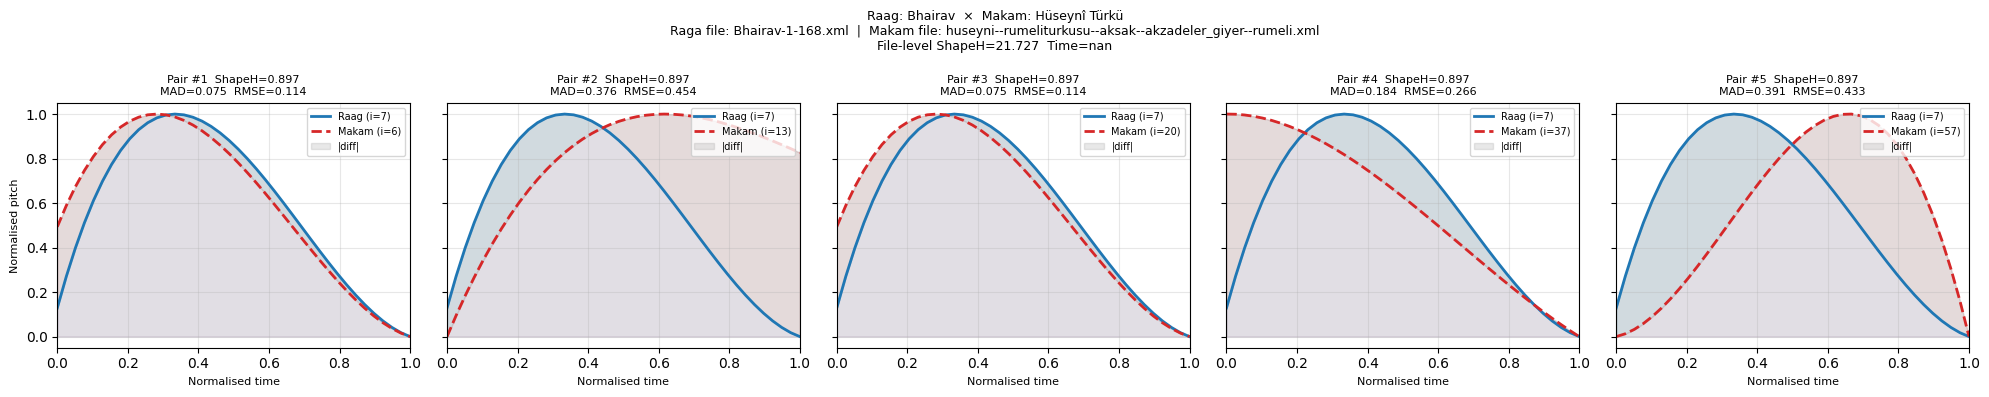

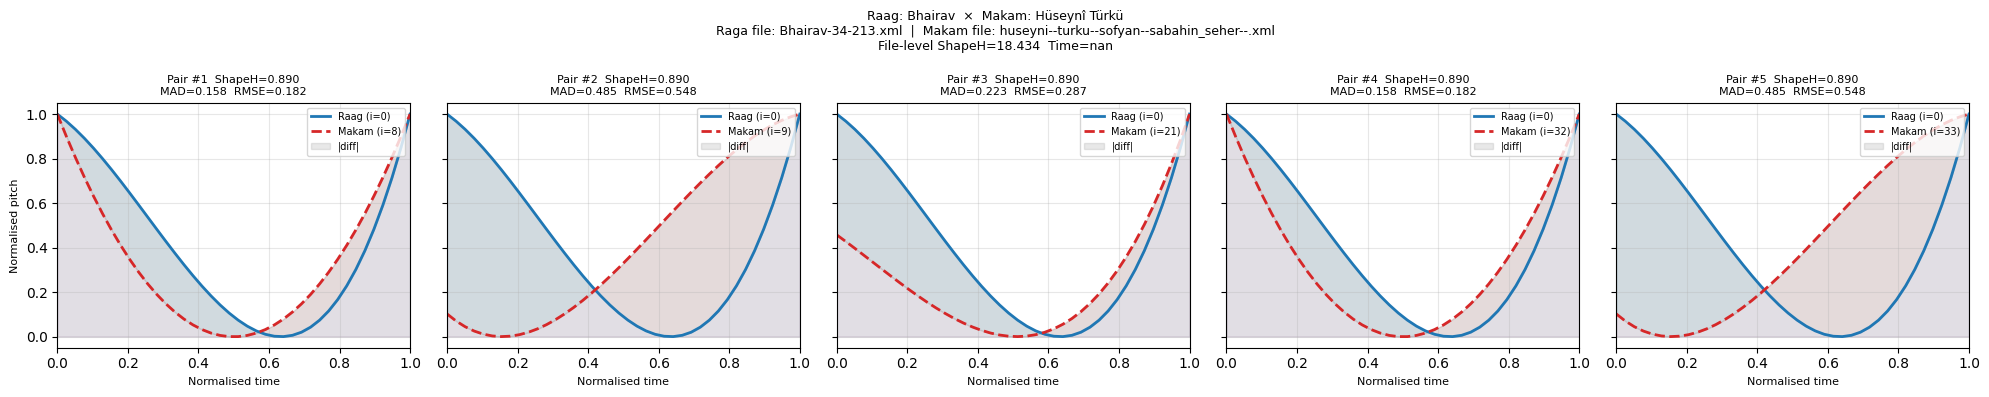

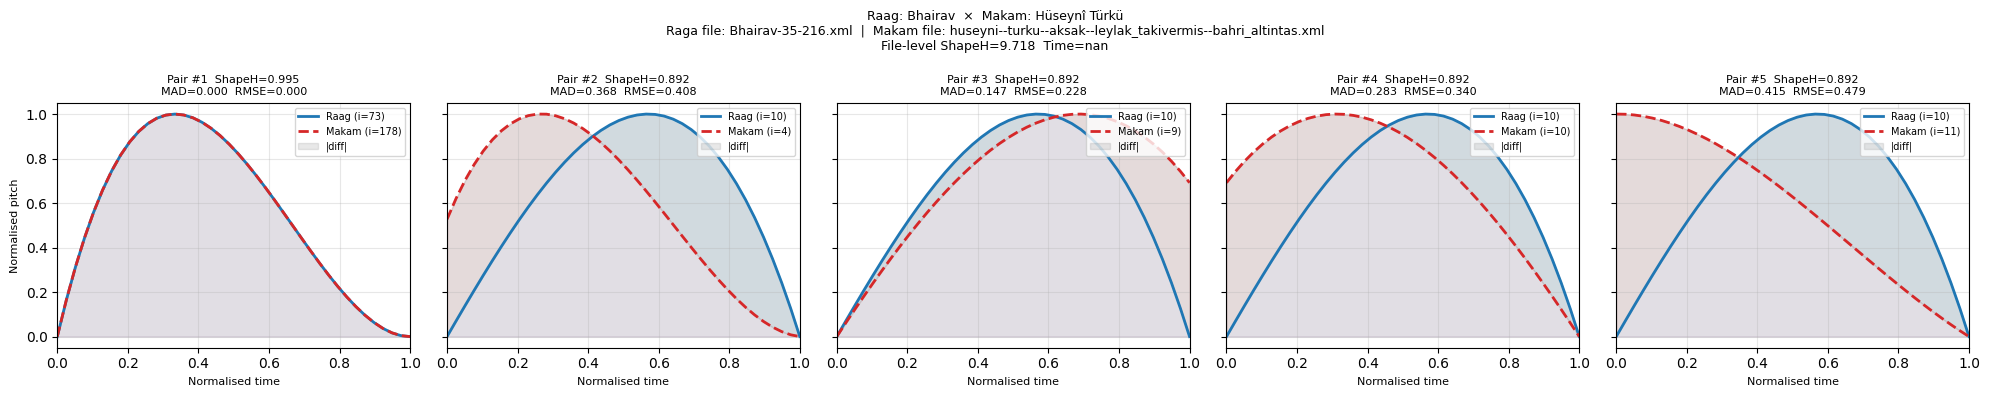

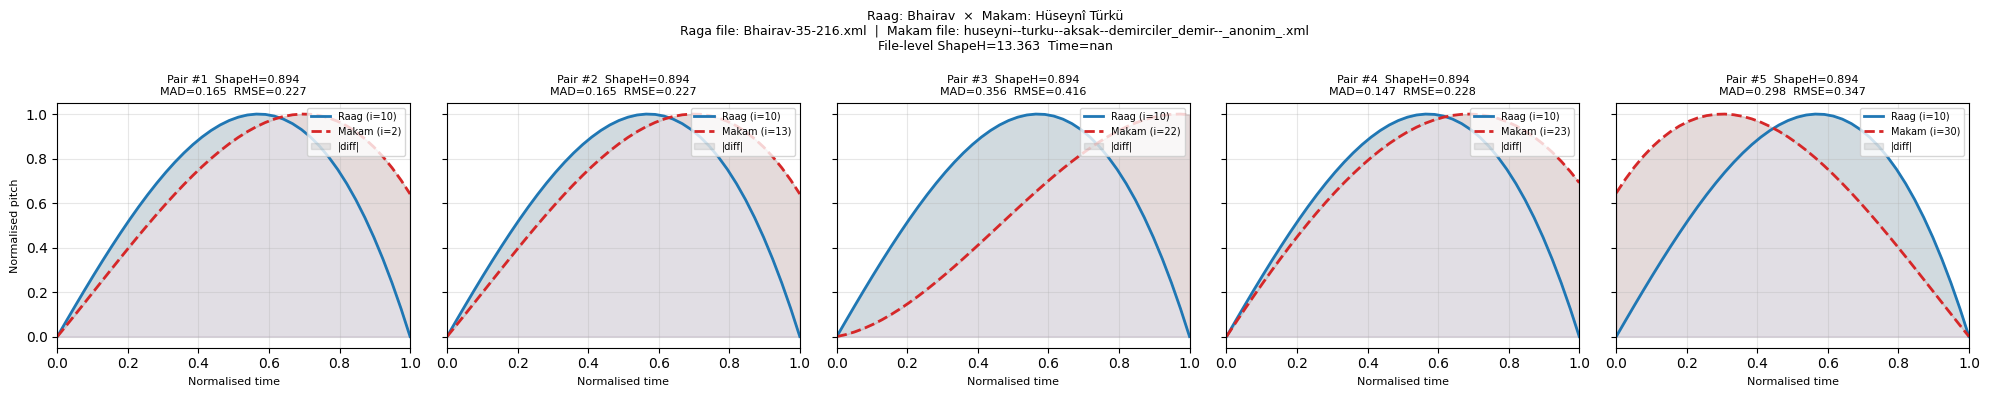

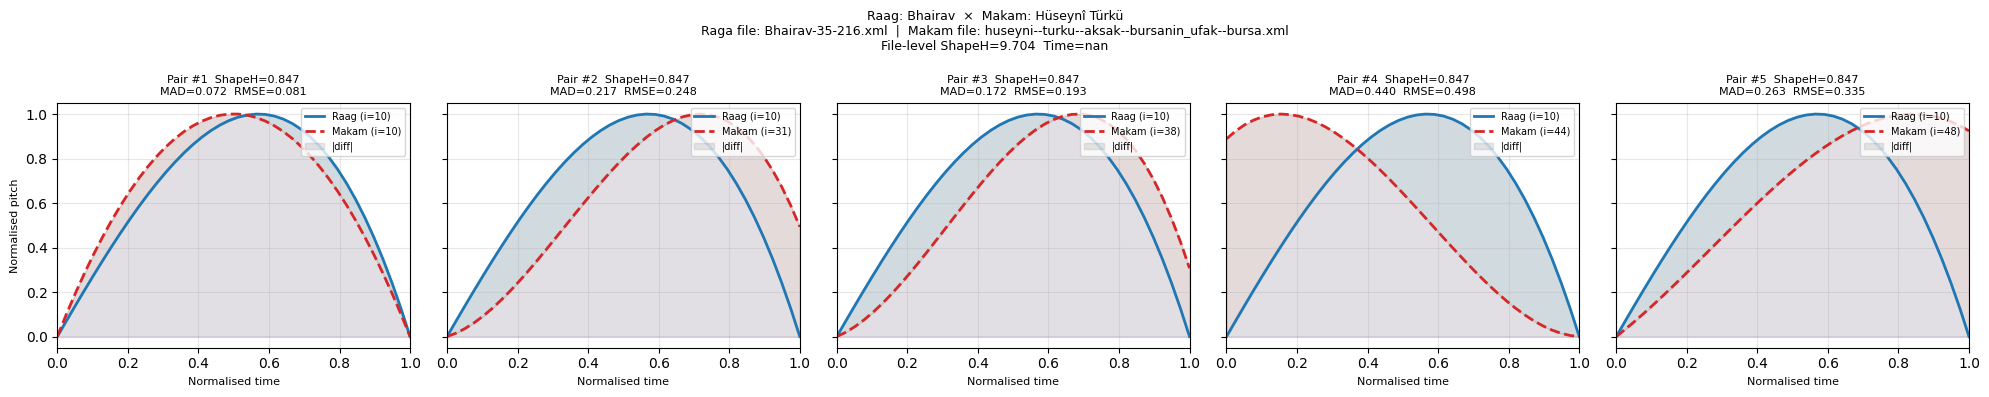

In [7]:
RAGA_COLOR  = "#1f77b4"
MAKAM_COLOR = "#d62728"

for pair_info in all_span_pairs[:TOP_N]:
    span_pairs = pair_info["span_pairs"]
    if not span_pairs:
        print(f"No span pairs for {pair_info['raga_file']} × {pair_info['makam_file']}")
        continue

    n_plots = min(TOP_N, len(span_pairs))
    fig, axes = plt.subplots(1, n_plots, figsize=(4 * n_plots, 4), sharey=True)
    if n_plots == 1:
        axes = [axes]

    fig.suptitle(
        f"Raag: {RAGA_NAME}  ×  Makam: {MAKAM_NAME}\n"
        f"Raga file: {pair_info['raga_file']}  |  Makam file: {pair_info['makam_file']}\n"
        f"File-level ShapeH={pair_info['shapeh_score']:.3f}  "
        f"Time={pair_info['time_score']:.3f}",
        fontsize=9
    )

    for ax_idx, (ri, mi, rspan, mspan, score) in enumerate(span_pairs[:n_plots]):
        ax = axes[ax_idx]

        t_r, p_r = span_to_curve(rspan)
        t_m, p_m = span_to_curve(mspan)

        ax.plot(t_r, p_r, color=RAGA_COLOR,  lw=2,   label=f"Raag (i={ri})")
        ax.fill_between(t_r, p_r, alpha=0.12, color=RAGA_COLOR)
        ax.plot(t_m, p_m, color=MAKAM_COLOR, lw=2, ls="--", label=f"Makam (i={mi})")
        ax.fill_between(t_m, p_m, alpha=0.08, color=MAKAM_COLOR)

        # Shade the difference
        ax.fill_between(t_r, p_r, p_m, alpha=0.18, color="gray", label="|diff|")

        mad   = mean_abs_distance(p_r, p_m)
        rmse  = rmse_distance(p_r, p_m)
        ax.set_title(f"Pair #{ax_idx+1}  ShapeH={score:.3f}\nMAD={mad:.3f}  RMSE={rmse:.3f}", fontsize=8)
        ax.set_xlabel("Normalised time", fontsize=8)
        ax.set_ylabel("Normalised pitch" if ax_idx == 0 else "", fontsize=8)
        ax.set_xlim(0, 1);  ax.set_ylim(-0.05, 1.05)
        ax.legend(fontsize=7, loc="upper right")
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## Compare Curves Using Multiple Distance Metrics

For the **best file pair** we collect all four curve-distance metrics for every top span pair:

$$\text{MAD} = \frac{1}{N}\sum_{i}|p^{(r)}_i - p^{(m)}_i|, \quad
\text{RMSE} = \sqrt{\frac{1}{N}\sum_{i}(p^{(r)}_i - p^{(m)}_i)^2}$$

plus **Discrete Fréchet** and **Hausdorff** distances on the 2-D point sequences $\{(t_i, p_i)\}$.

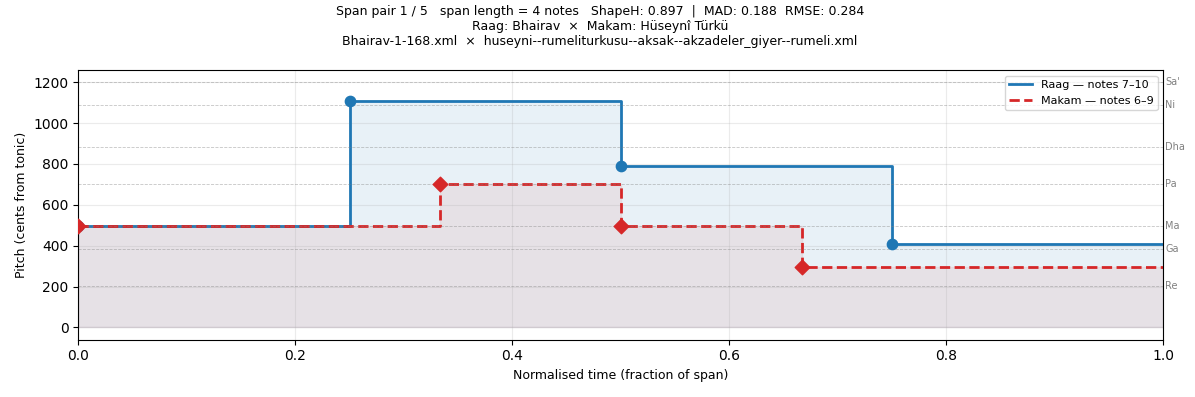

In [10]:
import ipywidgets as widgets
from IPython.display import display as ipy_display

NOTE_GRID = {
    "Sa":   0,
    "Re":   204,
    "Ga":   386,
    "Ma":   498,
    "Pa":   702,
    "Dha":  884,
    "Ni":  1088,
    "Sa'": 1200,
}


def notes_to_step_curve(notes_chunk):
    """Step-function pitch curve from (pitch_cents, duration_beats) pairs.
    Time axis normalised to [0, 1]; pitch in raw cents."""
    xs, ys = [], []
    t = 0.0
    for pitch, dur in notes_chunk:
        xs.extend([t, t + dur])
        ys.extend([pitch, pitch])
        t += dur
    xs = np.array(xs, dtype=float)
    ys = np.array(ys, dtype=float)
    return xs / t if t > 0 else xs, ys


if not all_span_pairs:
    print("No span pairs available — run the cells above first.")
else:
    file_options = [
        (f"{p['raga_file']}  ×  {p['makam_file']}", i)
        for i, p in enumerate(all_span_pairs)
    ]

    file_dropdown = widgets.Dropdown(
        options=file_options,
        description="File pair:",
        layout=widgets.Layout(width="700px"),
        style={"description_width": "80px"},
    )

    span_len_slider = widgets.IntSlider(
        min=4, max=32, step=1, value=SPAN_N,
        description="Span length (notes):",
        style={"description_width": "160px"},
        layout=widgets.Layout(width="420px"),
    )

    pair_slider = widgets.IntSlider(
        min=1, max=TOP_N, step=1, value=1,
        description="Span pair #:",
        style={"description_width": "90px"},
        layout=widgets.Layout(width="300px"),
    )

    out = widgets.Output()
    _span_cache: dict = {}

    def get_span_pairs(file_idx: int, span_len: int):
        key = (file_idx, span_len)
        if key not in _span_cache:
            pi = all_span_pairs[file_idx]
            r_spans = build_spans(pi["raga_notes"],  span_len)
            m_spans = build_spans(pi["makam_notes"], span_len)
            if not r_spans or not m_spans:
                _span_cache[key] = []
            else:
                freq = compute_span_frequencies([m_spans])
                results = [
                    (i, j, rs, ms, shapeh_similarity([rs], [ms], freq))
                    for i, rs in enumerate(r_spans)
                    for j, ms in enumerate(m_spans)
                ]
                results.sort(key=lambda x: x[4], reverse=True)
                _span_cache[key] = results[:TOP_N]
        return _span_cache[key]

    def plot_phrase(file_idx, span_len, pair_rank):
        pair_info  = all_span_pairs[file_idx]
        span_pairs = get_span_pairs(file_idx, span_len)

        if not span_pairs:
            print(f"No spans of length {span_len} found for this file pair.")
            return

        pair_rank  = min(pair_rank, len(span_pairs))
        ri, mi, rspan, mspan, score = span_pairs[pair_rank - 1]

        raga_chunk  = pair_info["raga_notes"][ri  : ri  + span_len]
        makam_chunk = pair_info["makam_notes"][mi : mi + span_len]

        t_r, p_r = notes_to_step_curve(raga_chunk)
        t_m, p_m = notes_to_step_curve(makam_chunk)

        # metrics on pitch normalised to [0,1]
        grid = np.linspace(0, 1, 300)
        p_r_n = (p_r - p_r.min()) / (p_r.max() - p_r.min() + 1e-9)
        p_m_n = (p_m - p_m.min()) / (p_m.max() - p_m.min() + 1e-9)
        mad  = mean_abs_distance(np.interp(grid, t_r, p_r_n), np.interp(grid, t_m, p_m_n))
        rmse = rmse_distance(   np.interp(grid, t_r, p_r_n), np.interp(grid, t_m, p_m_n))

        fig, ax = plt.subplots(figsize=(12, 4))

        # ── Raga curve ──────────────────────────────────────────────────────
        ax.step(t_r, p_r, where="post", color=RAGA_COLOR, lw=2.0,
                label=f"Raag — notes {ri}–{ri+span_len-1}")
        ax.fill_between(t_r, p_r, alpha=0.10, color=RAGA_COLOR, step="post")
        onsets_r = np.array([0.0] + list(np.cumsum([d for _, d in raga_chunk[:-1]])))
        total_r  = sum(d for _, d in raga_chunk)
        ax.scatter(onsets_r / total_r, [pc for pc, _ in raga_chunk],
                   color=RAGA_COLOR, s=55, zorder=5)

        # ── Makam curve ─────────────────────────────────────────────────────
        ax.step(t_m, p_m, where="post", color=MAKAM_COLOR, lw=2.0, ls="--",
                label=f"Makam — notes {mi}–{mi+span_len-1}")
        ax.fill_between(t_m, p_m, alpha=0.08, color=MAKAM_COLOR, step="post")
        onsets_m = np.array([0.0] + list(np.cumsum([d for _, d in makam_chunk[:-1]])))
        total_m  = sum(d for _, d in makam_chunk)
        ax.scatter(onsets_m / total_m, [pc for pc, _ in makam_chunk],
                   color=MAKAM_COLOR, s=55, zorder=5, marker="D")

        # ── Scale-degree reference lines ────────────────────────────────────
        p_all = np.concatenate([p_r, p_m])
        for name, cents in NOTE_GRID.items():
            if (p_all.min() - 150) <= cents <= (p_all.max() + 150):
                ax.axhline(cents, color="gray", ls="--", lw=0.6, alpha=0.45)
                ax.text(1.002, cents, name, transform=ax.get_yaxis_transform(),
                        va="center", fontsize=7, color="gray")

        ax.set_xlabel("Normalised time (fraction of span)", fontsize=9)
        ax.set_ylabel("Pitch (cents from tonic)", fontsize=9)
        ax.legend(fontsize=8, loc="upper right")
        ax.grid(True, alpha=0.25)
        ax.set_xlim(0, 1)

        fig.suptitle(
            f"Span pair {pair_rank} / {len(span_pairs)}   span length = {span_len} notes   "
            f"ShapeH: {score:.3f}  |  MAD: {mad:.3f}  RMSE: {rmse:.3f}\n"
            f"Raag: {RAGA_NAME}  ×  Makam: {MAKAM_NAME}\n"
            f"{pair_info['raga_file']}  ×  {pair_info['makam_file']}",
            fontsize=9,
        )
        plt.tight_layout()
        plt.show()

    def on_change(_):
        out.clear_output(wait=True)
        with out:
            plot_phrase(file_dropdown.value, span_len_slider.value, pair_slider.value)

    file_dropdown.observe(on_change, names="value")
    span_len_slider.observe(on_change, names="value")
    pair_slider.observe(on_change, names="value")

    ipy_display(widgets.VBox([
        file_dropdown,
        widgets.HBox([span_len_slider, pair_slider]),
        out,
    ]))
    on_change(None)

### Aggregated similarity plots

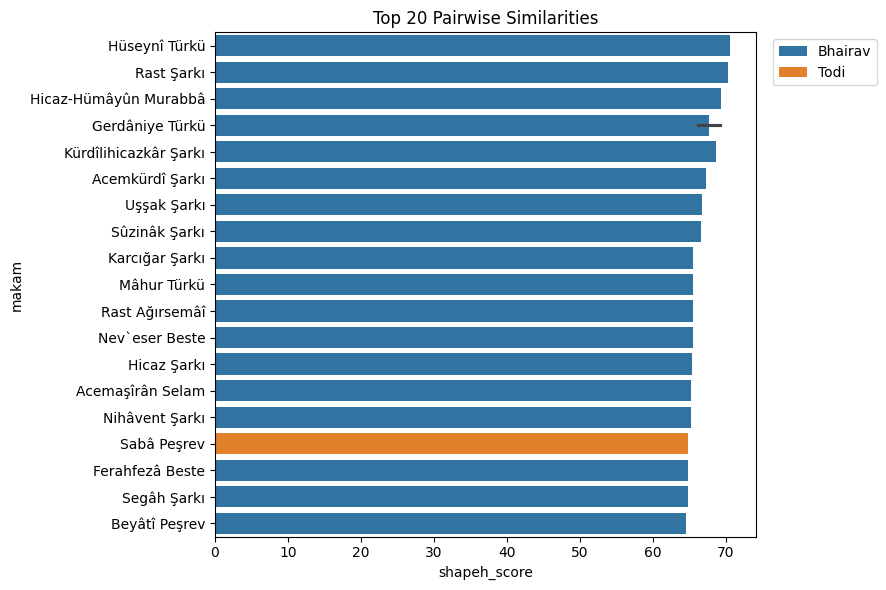

In [16]:
# Bhairav is the most similar raag to makams

top_n = 20
top_pairs = df_pair.nlargest(top_n, "shapeh_score")

plt.figure(figsize=(9,6))
sns.barplot(
    data=top_pairs,
    y="makam",
    x="shapeh_score",
    hue="raga",
    dodge=False
)
plt.title(f"Top {top_n} Pairwise Similarities")
plt.xlabel("shapeh_score")
plt.ylabel("makam")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

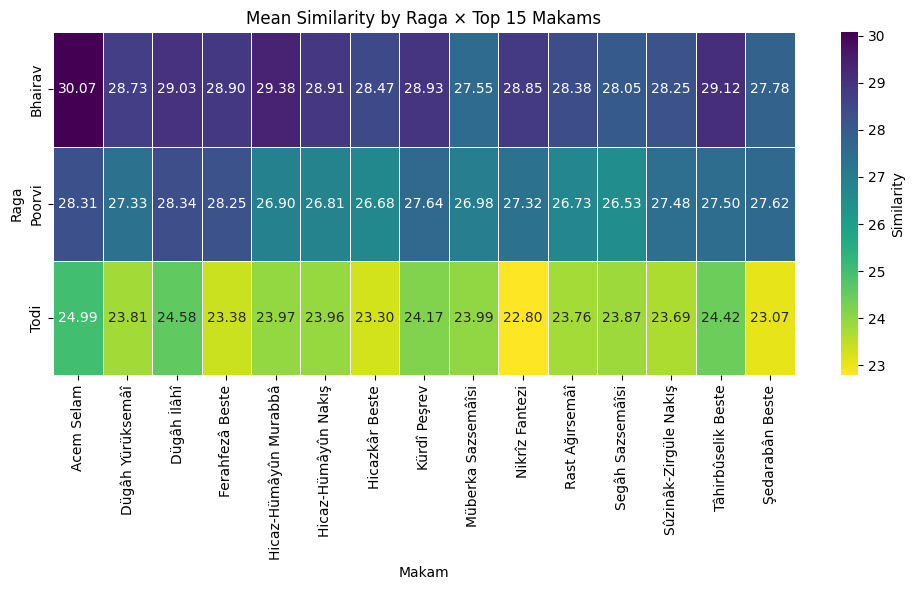

In [30]:
TOP_N = 15

# pick top makams by overall mean similarity
top_makams = (
    df_agg[df_agg["agg"] == "mean"]
    .groupby("makam")["value"]
    .mean()
    .sort_values(ascending=False)
    .head(TOP_N)
    .index
)

filtered = df_agg[
    (df_agg["agg"] == "mean") &
    (df_agg["makam"].isin(top_makams))
]

pivot_rm = filtered.pivot_table(
    index="raga",
    columns="makam",
    values="value"
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    pivot_rm,
    cmap="viridis_r",
    vmin=pivot_rm.min().min(),
    vmax=pivot_rm.max().max(),
    annot=True,      # show numbers
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Similarity"}
)

plt.title(f"Mean Similarity by Raga × Top {TOP_N} Makams")
plt.xlabel("Makam")
plt.ylabel("Raga")

plt.tight_layout()
plt.show()